[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/llm-regime-allocator/blob/main/notebooks/nb01_data_and_baselines.ipynb)

In [1]:
# Colab setup: fetch the repo (data, results and the replayable LLM cache), work from its notebooks/ folder.
# Runs only on Colab; locally this cell does nothing. No API keys or paid calls are needed.
import os, subprocess, sys
if 'google.colab' in sys.modules and not os.path.exists('../src/lra'):
    repo = '/content/llm-regime-allocator'
    if not os.path.exists(repo):
        subprocess.run(['git', 'clone', '-q', '--depth', '1',
                        'https://github.com/FranQuant/llm-regime-allocator.git', repo], check=True)
    os.chdir(f'{repo}/notebooks')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pydantic>=2', 'scikit-learn'], check=True)

# nb01 — Data and baselines

**Question.** What must an LLM beat? Before any model is asked anything, this notebook fixes the inputs, the regime target and the no-LLM benchmarks that nb02–nb05 are judged against: data and baselines (nb01), then whether the LLM reads regimes or remembers them (nb02), portfolios (nb03), other model families (nb04), reading versus remembering (nb05) and a live test. Everything here is read from files written by `python scripts/run_baselines.py`; nothing is fitted in the notebook.

## Setup

**Data.** 13 macro series from FRED/ALFRED used point-in-time (vintages as published, plus release lags) and daily adjusted prices for 8 ETFs: SPY, EEM, IEF, TIP, HYG, DBC, GLD, BIL. Decisions are taken at month-end close from 2007-12-31 to 2026-04-30 (221 holding months, held to 2026-05-29). A **snapshot** (the "context pack" of the code, "pack" in table labels) is what a forecaster sees on a decision date.

**Target.** Four regimes from the growth × inflation quadrant: Goldilocks (growth ↑, inflation ↓), Reflation (↑ ↑), Stagflation (↓ ↑), Risk-Off (↓ ↓). The **realised** regime is the quadrant over the *next* three months, labelled with today's data vintage; 217 months have one.

**Forecasters (no LLM).** *Uniform* (25% each) is the no-skill control. *Climatology* is the base rate of labels already published. The *rule* is a persistence forecast: the quadrant of the 6-month trend in the 3-month average of industrial-production and CPI year-on-year rates. *Logit* and *GBT* (logistic regression, gradient boosting) are trained walk-forward on labels published by the decision date.

**Scores.** With forecast $p_{t,k}$ and one-hot realised regime $y_{t,k}$ over $N$ labelled months,
$$\text{Brier}=\frac1N\sum_t\sum_k (p_{t,k}-y_{t,k})^2,\qquad \text{log-loss}=-\frac1N\sum_t \ln p_{t,y_t}.$$
Uniform scores a Brier of 0.750 and a log-loss of $\ln 4=1.386$; lower is better. Hit rate is the share of months where the top call is right.

**Portfolios.** A playbook maps probabilities to ETF weights, $w_t=\sum_k p_{t,k}\,w^{(k)}$, with four fixed regime portfolios $w^{(k)}$ set ex ante in `configs/strategy.toml` (the rule uses a hard 0/1 $p$). Monthly rebalancing, 2.5 bps on traded notional, Sharpe on daily returns in excess of BIL.

**Scoring code.** Scores are computed with `lra.evaluation` (the rule is turned into probabilities with 85% on its call, 5% elsewhere; log-loss probabilities are floored at 1e-3) and climatology is the point-in-time version from `regimes_fair.csv`, so every number here matches `results/h1/scores.csv` and nb02.

In [2]:
import sys
sys.path.insert(0, '../src')
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from lra import evaluation as ev
R = Path('../results/baselines')
REG = ['Goldilocks', 'Reflation', 'Stagflation', 'Risk_Off']
# regimes (separate from the model colours used in nb02-nb05 figures): Goldilocks, Reflation, Stagflation, Risk_Off
C = ['#7e57c2', '#e0559c', '#8d6e3f', '#1f3a5f']
GREY = {'sixty_forty': '#0b0b0b', 'rule_playbook': '#52514e', 'ml_logit_playbook': '#8a8984', 'ml_gbt_playbook': '#b5b4ae'}  # baselines
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2,
                     'axes.edgecolor': '#52514e', 'text.color': '#0b0b0b'})

def fmt(df, pct=(), d0=(), d1=(), d2=()):
    """Display only: Sharpe 2 decimals, Brier 3, percentages 0 (stored results are untouched)."""
    f = {**{c: '{:.0%}' for c in pct}, **{c: '{:.0f}' for c in d0}, **{c: '{:.1f}' for c in d1}, **{c: '{:.2f}' for c in d2}}
    return df.style.format(f, precision=3, na_rep='–')
met = pd.read_csv(R / 'metrics.csv')
reg = pd.read_csv(R / 'regimes.csv', parse_dates=['date'], index_col='date')
daily = pd.read_csv(R / 'daily_returns.csv', parse_dates=[0], index_col=0)
feat = pd.read_csv(R / 'features.csv', parse_dates=['date'], index_col='date')

## 1. The snapshot

One row per decision date: 13 macro indicators × (level, 3-month change, 12-month change, 36-month z-score), 7 market roles × (1/3/6/12-month return, 6-month volatility, 12-month drawdown), plus the 6-month stock–bond correlation. Column names carry roles, never tickers or dates.

In [3]:
print(feat.shape)
cov = feat.notna().mean().groupby(lambda c: c.split('_')[0]).mean()
print('share of non-missing values by block:'); print(cov.map('{:.0%}'.format))
feat.loc['2008-09-30'].filter(like='macro_').filter(like='_level').round(2)

(282, 95)
share of non-missing values by block:
macro    98%
mkt      98%
dtype: str


macro_growth_indpro_yoy_level    -1.49
macro_growth_cfnai_ma3_level     -1.06
macro_labour_unrate_level         6.10
macro_labour_payems_3m_level    -81.33
macro_infl_cpi_yoy_level          5.36
macro_infl_core_yoy_level         2.55
macro_policy_ffr_level            1.56
macro_rates_2y_level              1.70
macro_rates_10y_level             3.61
macro_curve_10y2y_level           1.91
macro_risk_vix_level             46.72
macro_credit_baa10y_level         4.01
macro_usd_broad_yoy_level        -0.90
Name: 2008-09-30 00:00:00, dtype: float64

**Reading.** 95 features on 282 monthly rows (from 2002-12, so the ML models have history before the first decision), about 98% populated. September 2008 in raw levels (unemployment 6.1%, CPI 5.4% year on year, VIX 46.7) is the kind of figure from which a model can name the month; nb02 tests that.

## 2. Regimes and no-LLM forecasts

Each forecaster is scored against the realised regime of the next three months. The rule is a persistence forecast; climatology and the ML models are walk-forward.

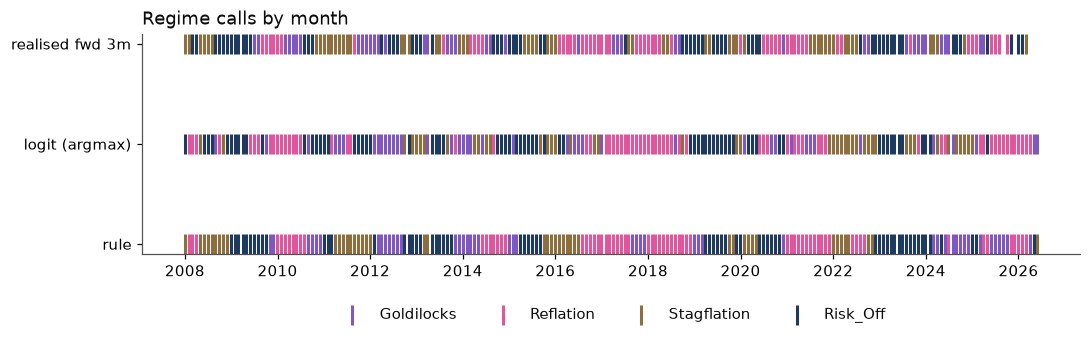

In [4]:
fig, ax = plt.subplots(figsize=(11, 2.6))
rows = {'rule': reg['rule'], 'logit (argmax)': reg[[f'logit_{k}' for k in REG]].idxmax(axis=1).str[6:],
        'realised fwd 3m': reg['realised_forward']}
for y, (name, s) in enumerate(rows.items()):
    for k, c in zip(REG, C):
        d = s.index[s == k]
        ax.scatter(d, [y] * len(d), marker='|', s=180, color=c, label=k if y == 0 else None)
ax.set_yticks(range(len(rows)), list(rows)); ax.grid(False)
ax.legend(ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.18), frameon=False)
ax.set_title('Regime calls by month', loc='left'); plt.show()

**Reading.** The realised regime (top row) changes every few months, so a three-month-ahead call has little persistence to lean on; none of the three rows lines up with it month by month.

In [5]:
y = reg['realised_forward'].dropna()
fair = pd.read_csv(R / 'regimes_fair.csv', parse_dates=['date'], index_col='date')
cols = lambda df, p: df[[f'{p}_{k}' for k in REG]].set_axis(REG, axis=1)
fc = {'uniform 25% (hit rate = argmax artefact)': ev.uniform(reg.index),
      'climatology (point-in-time)': cols(fair, 'climatology'),
      'rule (persistence, 85% on its call)': ev.hard(reg['rule']),
      'ml logit': cols(reg, 'logit'), 'ml gbt': cols(reg, 'gbt')}
scores = pd.DataFrame({k: ev.score(p, y) for k, p in fc.items()}).T.drop(columns='n')
print(f'{len(y)} labelled months'); fmt(scores, pct=['hit_rate'])

217 labelled months


,hit_rate,brier,log_loss
uniform 25% (hit rate = argmax artefact),19%,0.750,1.386
climatology (point-in-time),16%,0.770,1.427
"rule (persistence, 85% on its call)",33%,1.099,2.056
ml logit,37%,0.861,1.761
ml gbt,32%,0.880,1.730


**Reading.** **Key finding:** no baseline beats uniform on Brier (0.750): climatology scores 0.770, the best ML models 0.861 (logit) and 0.880 (GBT), and the rule is punished for its confident calls (1.099). Hit rates of 16–37% are modest against 25% for chance (uniform's 19% is a tie-breaking artefact). The bar for the LLM is uniform and climatology on Brier and log-loss, and ML on identical inputs.

## 3. Baseline portfolios (net of 2.5 bps)

Regime playbooks driven by the rule and the ML forecasts, against 60/40 and Black-Litterman (BL) benchmarks.

In [6]:
head = met[met.cost_bps == 2.5].drop(columns='cost_bps').set_index('strategy')
fmt(head, pct=['ann_return', 'ann_vol', 'max_drawdown'], d2=['sharpe', 'calmar', 'turnover_per_year'])

,ann_return,ann_vol,sharpe,max_drawdown,calmar,turnover_per_year
strategy,,,,,,
sixty_forty,8%,11%,0.66,-32%,0.26,0.11
reference_static,7%,10%,0.57,-32%,0.22,0.13
rule_playbook,6%,8%,0.62,-21%,0.29,1.09
ml_logit_playbook,6%,8%,0.64,-26%,0.25,1.20
ml_gbt_playbook,7%,7%,0.75,-18%,0.37,1.51
bl_equilibrium,7%,10%,0.57,-32%,0.22,0.13
bl_momentum,9%,16%,0.53,-35%,0.26,2.76


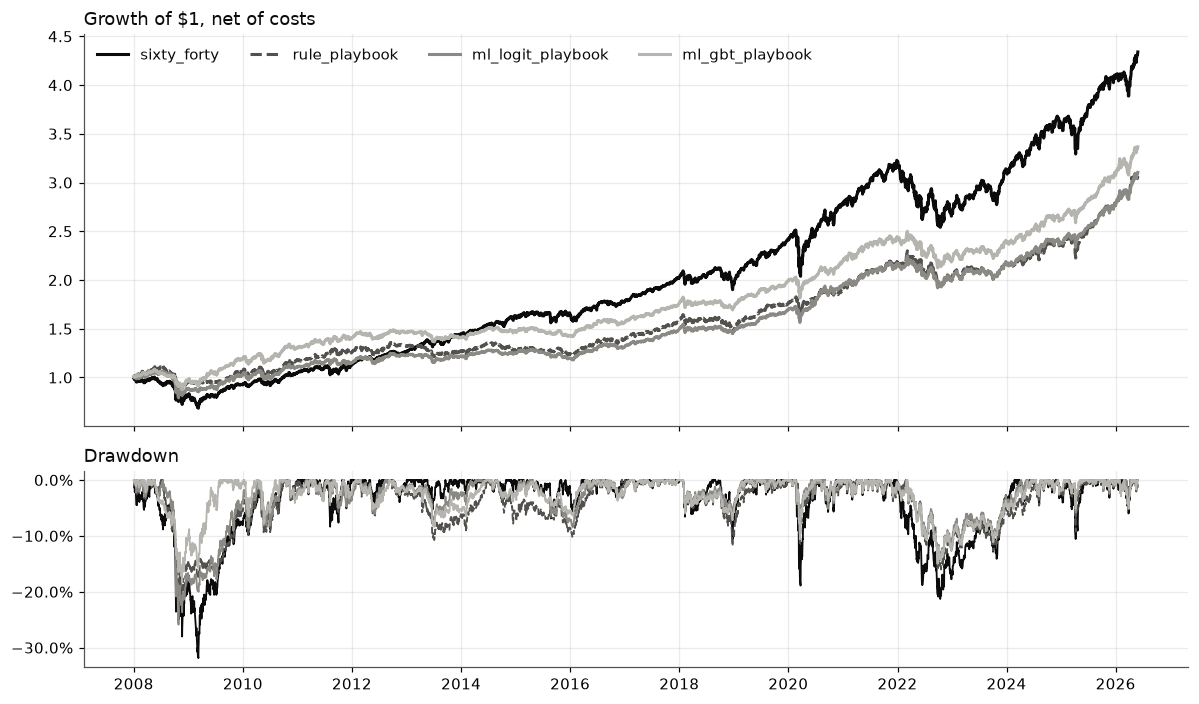

In [7]:
show = ['sixty_forty', 'rule_playbook', 'ml_logit_playbook', 'ml_gbt_playbook']
wealth = (1 + daily[show]).cumprod()
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, height_ratios=[2, 1])
for s in show:
    c, ls = GREY[s], ('--' if s == 'rule_playbook' else '-')
    a1.plot(wealth.index, wealth[s], color=c, label=s, linestyle=ls)
    a2.plot(wealth.index, wealth[s] / wealth[s].cummax() - 1, color=c, linewidth=1.2, linestyle=ls)
a1.set_title('Growth of $1, net of costs', loc='left'); a1.legend(frameon=False, ncol=4, loc='upper left')
a2.set_title('Drawdown', loc='left'); a2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
plt.tight_layout(); plt.show()

**Reading.** The playbooks (greys; the rule is dashed) grow more slowly than 60/40 (black) but fall less in 2008–09 and 2022.

In [8]:
sens = met.pivot(index='strategy', columns='cost_bps', values='sharpe')
sens.columns = [f'{c:g} bps' for c in sens.columns]
print('Sharpe by cost level'); sens.style.format('{:.2f}')

Sharpe by cost level


,0 bps,2.5 bps,5 bps,10 bps
strategy,,,,
bl_equilibrium,0.57,0.57,0.57,0.57
bl_momentum,0.54,0.53,0.53,0.51
ml_gbt_playbook,0.76,0.75,0.74,0.72
ml_logit_playbook,0.64,0.64,0.63,0.61
reference_static,0.57,0.57,0.57,0.57
rule_playbook,0.63,0.62,0.61,0.60
sixty_forty,0.66,0.66,0.65,0.65


**Reading.** **Key finding:** regime playbooks cut volatility and drawdown against 60/40 (GBT playbook: Sharpe 0.75, maximum drawdown −18%, against 0.66 and −32%) at 1.1–1.5 one-way turnover a year, and costs barely matter: going from 0 to 10 bps lowers Sharpe by at most 0.04. **Control:** `bl_equilibrium` equals `reference_static` by construction (no views, so BL returns the reference portfolio): a sanity check, not a strategy. **Caveat:** one path of 221 months; the standard error of an annualised Sharpe is about 0.24, so differences of this size are not a ranking.

## What we can and cannot claim

- **No no-LLM forecaster beats uniform on Brier** (best 0.861, against 0.750).
- **Playbooks trade return for risk.** They earn less than 60/40 (6–7% a year against 8%) for lower volatility and drawdown; a Sharpe edge of 0.1 is within noise.
- **Labels use the data-end vintage.** nb02 section 6 shows that first-release labels change 33 of 217 months and no ranking.
- **Not shown here:** that any forecaster, LLM included, adds information beyond these baselines.

## Next

nb02 puts the LLM on the same snapshots and asks whether its forecasts come from reading them or from remembering the month.